In [31]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
#import scipy.stats as stats
from datetime import datetime, timedelta
#import openpyxl

In [32]:
#Annual risk free rate
rf = 0.04

#input params indices - is used to calculate spread
index1= "^MOVE" #Said to be the VIX of bonds
index2= "^VIX"

#Tradable securities - proxies used to trade the spread
ticker1 = "^MOVE"
ticker2 = "^VIX"

hp_short = 1 #holding period (number of days) for the short position
hp_long = 3  #holding period (number of days) for the long position

#input params for the strategy
zscore_threshold = 2.0 #standard is 2

#input params for the backtest
window = 60 #assumes SMA
start_date = "2020-01-01"
end_date = '2025-04-15' #not in use atm. The model just uses the latest available data

#Ensures the dates are in the correct format
start_date_parsed = datetime.strptime(start_date,"%Y-%m-%d")
end_date_parsed = datetime.strptime(end_date,"%Y-%m-%d")

benchmark_index = "SPY" #buy & hold benchmark


***Data import***

In [33]:
# Download data for given index1
i1 = yf.download(index1, start=start_date_parsed)["Close"]
i1.name = f"{index1}"

# Download data for given index2
i2 = yf.download(index2, start=start_date_parsed)["Close"]
i2.name = f"{index2}"

# Download ticker1 and ticker2 as proxies for indices (should be Nordnet compatible)
t1 = yf.download(f"{ticker1}", start=start_date)["Close"]
t2 = yf.download(f"{ticker2}", start=start_date)["Close"]

# Combine and clean
data = pd.concat([i1, i2], axis=1).dropna()
data[f"{index1} % change"] = data[f"{index1}"].pct_change()
data[f"{index2} % change"] = data[f"{index2}"].pct_change()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [34]:
data.tail()

Ticker,^MOVE,^VIX,^MOVE % change,^VIX % change
Date,,,,
2025-04-10,128.350006,40.720001,-0.003726,0.211184
2025-04-11,137.259995,37.560001,0.069419,-0.077603
2025-04-14,132.460007,30.889999,-0.034970,-0.177583
2025-04-15,122.559998,30.120001,-0.074740,-0.024927
2025-04-16,119.400002,32.639999,-0.025783,0.083665


**Statistics comparison**

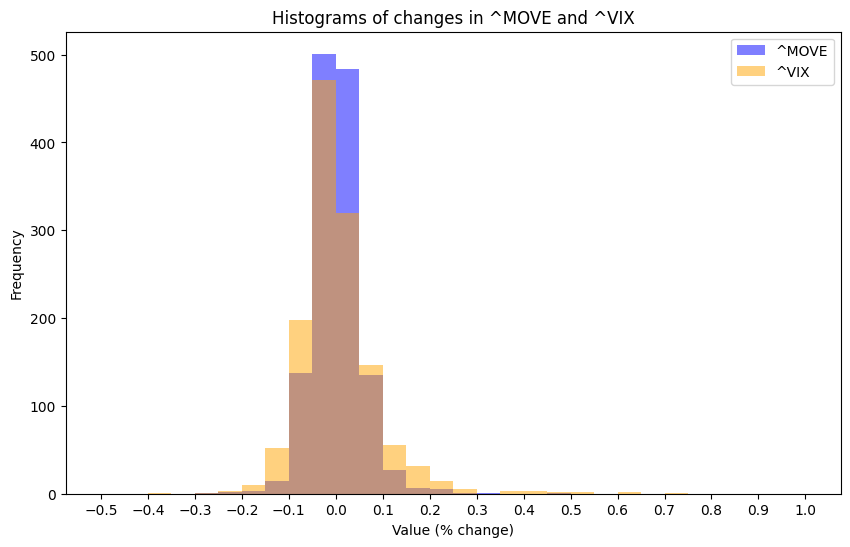

In [35]:
plt.figure(figsize=(10, 6))  # Set the figure size
plt.hist(data[f"{index1} % change"], bins=np.arange(-0.5, 1.05, 0.05), alpha=0.5, label=f"{index1}", color="blue")  # Histogram for i1
plt.hist(data[f"{index2} % change"], bins=np.arange(-0.5, 1.05, 0.05), alpha=0.5, label=f"{index2}", color="orange")  # Histogram for i2
plt.xticks(np.arange(-0.5, 1.05, 0.1))

# Add labels, title, and legend
plt.xlabel("Value (% change)")
plt.ylabel("Frequency")
plt.title(f"Histograms of changes in {index1} and {index2}")
plt.legend()

# Show the plot
plt.show()

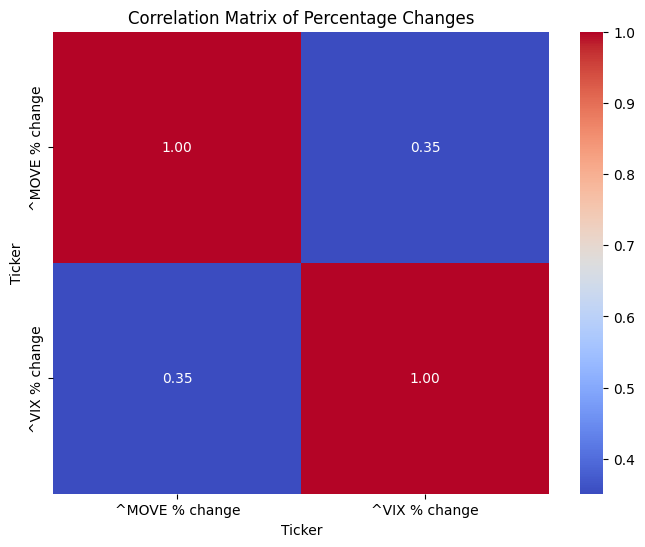

In [36]:
# Create a DataFrame with the percentage changes
correlation_data = data[[f"{index1} % change", f"{index2} % change"]].dropna()

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

# Plot the correlation matrix
plt.figure(figsize=(8, 6))  # Set the figure size
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)

# Add labels and title
plt.title("Correlation Matrix of Percentage Changes")
plt.show()

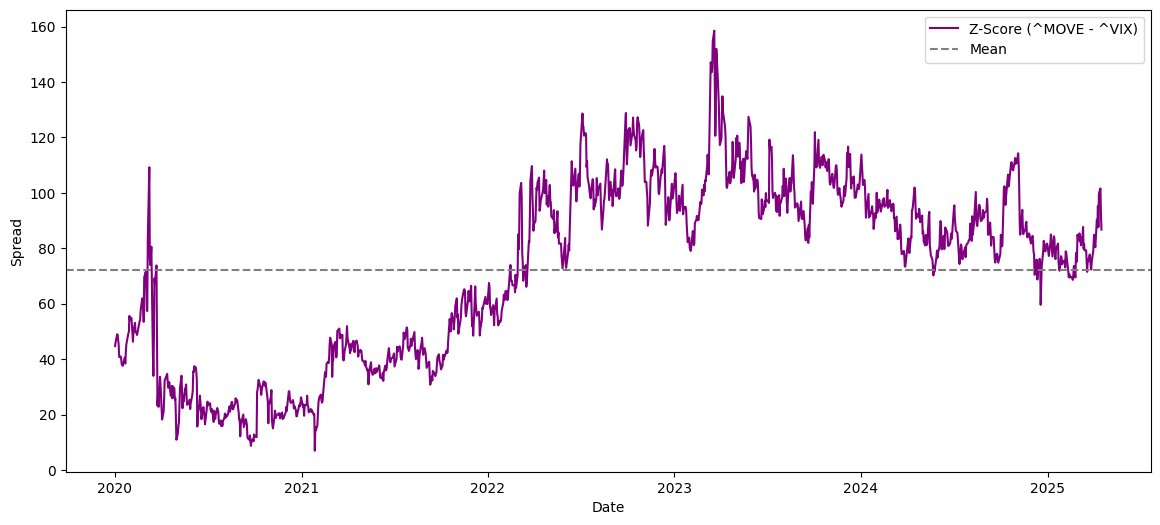

In [37]:
# Calculate divergence metrics
data["Spread"] = data[f"{index1}"] - data[f"{index2}"]
data["Ratio"] = data[f"{index1}"] / data[f"{index2}"]
data["Z_Score"] = (data["Spread"] - data["Spread"].rolling(window).mean()) / data["Spread"].rolling(window).std() #assumes rolling SMA


plt.figure(figsize=(14, 6))
plt.plot(data.index, data["Spread"], label=f"Z-Score ({index1} - {index2})", color="purple")
plt.axhline(data["Spread"].mean(), color="gray", linestyle="--", label="Mean")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.legend()
plt.show()

In [38]:
# Optional: Flag extreme events
data["Stress_Signal"] = data["Z_Score"].apply(lambda z: "High" if z > zscore_threshold else ("Low" if z < -zscore_threshold else "Neutral"))

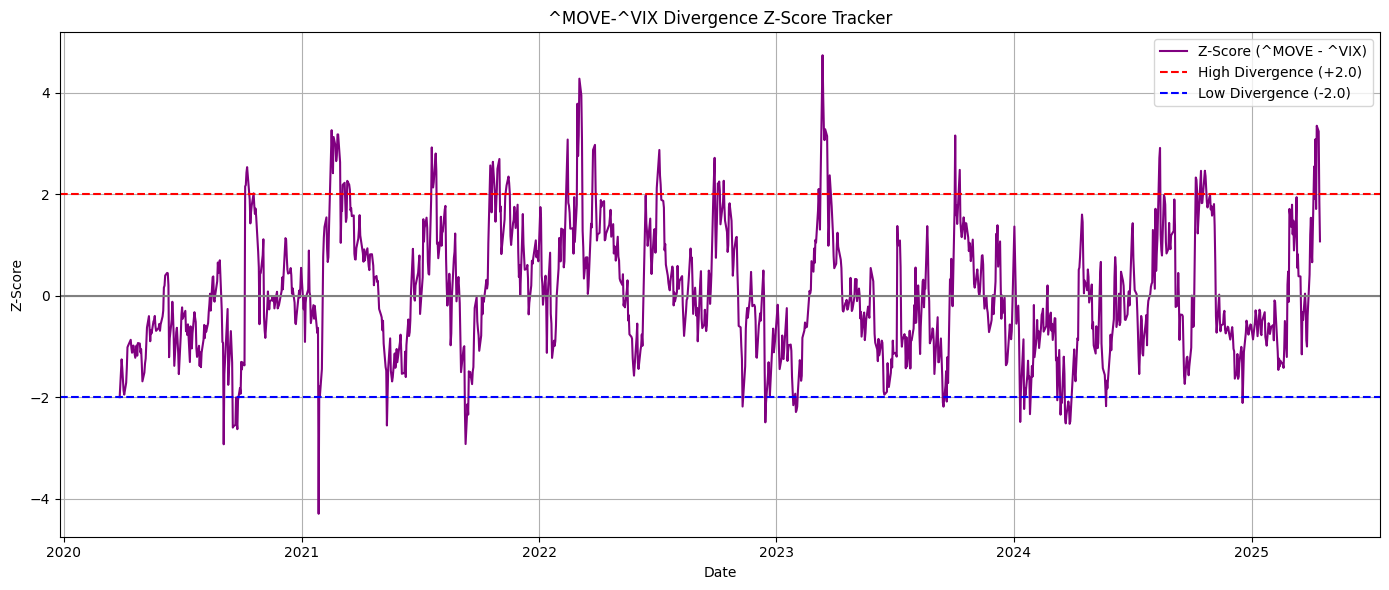

In [39]:
# Plot
plt.figure(figsize=(14, 6))
plt.plot(data.index, data["Z_Score"], label=f"Z-Score ({index1} - {index2})", color="purple")
plt.axhline(zscore_threshold, color="red", linestyle="--", label=f"High Divergence (+{zscore_threshold})")
plt.axhline(-zscore_threshold, color="blue", linestyle="--", label=f"Low Divergence (-{zscore_threshold})")
plt.axhline(0, color="gray", linestyle="-")
plt.title(f"{index1}-{index2} Divergence Z-Score Tracker")
plt.xlabel("Date")
plt.ylabel("Z-Score")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

***Strategy Framework***

In [40]:

# Combine with existing Z-score data
combined = pd.concat([data["Z_Score"], t1, t2], axis=1).dropna()
combined.columns = ["Z_Score", f"{ticker1}", f"{ticker2}"]

# Create trading signal:
# - If Z > threshold, simulate ticker1 short
# - If Z < -threshold, simulate ticker2 long 
combined["Signal"] = "Neutral"
combined.loc[combined["Z_Score"] > zscore_threshold, "Signal"] = f"Short_{ticker1}"
combined.loc[combined["Z_Score"] < -zscore_threshold, "Signal"] = f"Long_{ticker2}"

# Create position column (holding 1 day after signal trigger)
combined[f"Position_{ticker1}"] = combined["Signal"].shift(hp_short).apply(lambda x: -1 if x == f"Short_{ticker1}" else 0)
combined[f"Position_{ticker2}"] = combined["Signal"].shift(hp_long).apply(lambda x: 1 if x == f"Long_{ticker2}" else 0)

# Calculate daily returns
combined[f"Return_{ticker1}"] = combined[f"{ticker1}"].pct_change()
combined[f"Return_{ticker2}"] = combined[f"{ticker2}"].pct_change()

# Simulate strategy PnL
combined[f"PnL_{ticker1}"] = combined[f"Position_{ticker1}"] * combined[f"Return_{ticker1}"]
combined[f"PnL_{ticker2}"] = combined[f"Position_{ticker2}"] * combined[f"Return_{ticker2}"]
combined["PnL_Total"] = combined[f"PnL_{ticker1}"] + combined[f"PnL_{ticker2}"]
combined["Cumulative_Return"] = (1 + combined["PnL_Total"]).cumprod()


In [41]:
#review strategy dataFrame in excel
#combined.to_excel("combined_output.xlsx", index=True)  # Set index=True to include the index in the file

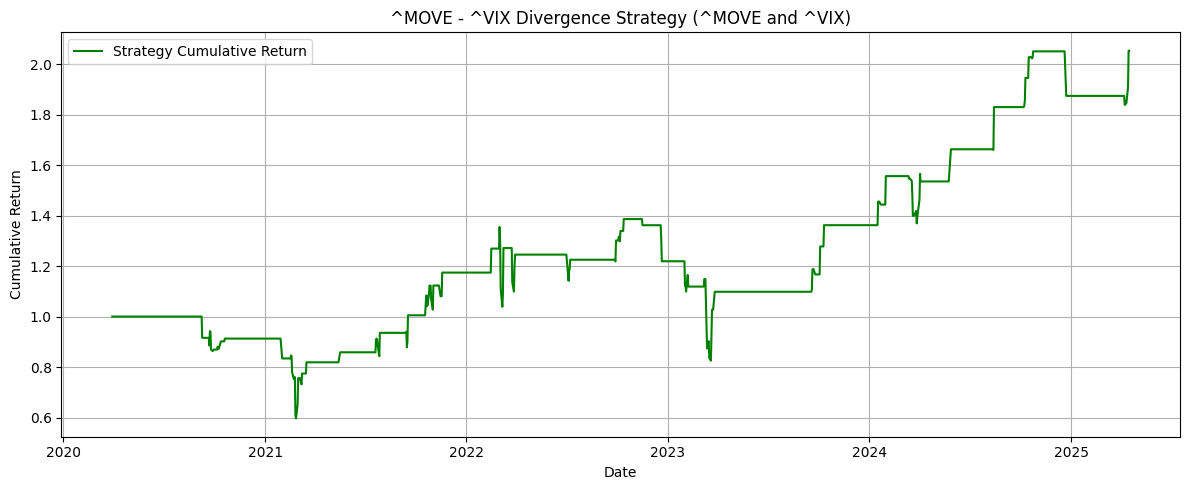

In [42]:
# Plot results
plt.figure(figsize=(12, 5))
plt.plot(combined["Cumulative_Return"], label="Strategy Cumulative Return", color="green")
plt.title(f"{ticker1} - {ticker2} Divergence Strategy ({ticker1} and {ticker2})")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
geo_ret = (combined["Cumulative_Return"].iloc[-1] - 1) * 100
cagr = (combined["Cumulative_Return"].iloc[-1] ** (252 / len(combined)) - 1) * 100
volatility = combined["PnL_Total"].std() * np.sqrt(252) * 100
sharpe_ratio = (cagr - rf) / volatility
max_drawdown = (combined["Cumulative_Return"].cummax() - combined["Cumulative_Return"]).max() * 100
#sortino_ratio = (cagr - 0) / combined["PnL_Total"][combined["PnL_Total"] < 0].std() * np.sqrt(252) * 100
calmar_ratio = cagr / abs(max_drawdown)

# Create a table for the performance metrics
performance_metrics = pd.DataFrame({
    "Metric": [
        "Geometric Avg. Return (%)",
        "CAGR (%)",
        "Volatility (%)",
        "Sharpe Ratio",
        "Max Drawdown (%)",
        #"Sortino Ratio",
        "Calmar Ratio"
    ],
    "Value": [
        f"{geo_ret:.2f}",
        f"{cagr:.2f}",
        f"{volatility:.2f}",
        f"{sharpe_ratio:.2f}",
        f"{max_drawdown:.2f}",
        #f"{sortino_ratio:.2f}",
        f"{calmar_ratio:.2f}"
    ]
})

# Display the table
performance_metrics

,Metric,Value
0,Geometric Avg. Return (%),105.30
1,CAGR (%),15.45
2,Volatility (%),31.09
3,Sharpe Ratio,0.50
4,Max Drawdown (%),56.07
5,Calmar Ratio,0.28


***Benchmark comparison***

In [44]:
# Create a comparison table
benchmark = yf.download(f"{benchmark_index}", start=data.index.min())["Close"]
benchmark_returns = benchmark.pct_change().dropna()
benchmark_cumulative = (1 + benchmark_returns).cumprod()
benchmark_volatility = benchmark_returns.std() * np.sqrt(252) * 100
benchmark_cagr = (benchmark_cumulative.iloc[-1] ** (252 / len(benchmark_returns)) - 1) * 100

comparison_table = pd.DataFrame({
    "Strategy": ["Your Portfolio", "Buy & Hold SPY"],
    "Return (CAGR %)": [f"{cagr:.2f}", f"{benchmark_cagr.values[0]:.2f}"],  # Extract scalar value from Series
    "Risk (Std Dev)": [f"{volatility:.2f}", f"{benchmark_volatility.values[0]:.2f}"],  # Extract scalar value from Series
    "Sharpe Ratio": [f"{sharpe_ratio:.2f}", f"{benchmark_returns.mean().values[0] / benchmark_returns.std().values[0]:.2f}"],  # Extract scalar values
})

comparison_table

[*********************100%***********************]  1 of 1 completed


,Strategy,Return (CAGR %),Risk (Std Dev),Sharpe Ratio
0,Your Portfolio,15.45,31.09,0.50
1,Buy & Hold SPY,11.20,21.61,0.04
